In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from catboost import CatBoostClassifier

In [2]:
df = pd.read_csv("train.csv")

In [3]:
x = df.drop(['id', 'Churn'], axis = 1)
y = df['Churn']

In [5]:
le = LabelEncoder()

y = le.fit_transform(y)

In [12]:
cat_cols = x.select_dtypes(include=['object', 'string']).columns

In [13]:
x = pd.get_dummies(x, drop_first=True)

In [16]:
x_train, x_valid, y_train, y_valid = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [17]:
model = CatBoostClassifier(
    verbose = 0,
    random_state = 42
)

model.fit(x_train, y_train)

CatBoostClassifier(random_state=42, verbose=0)

In [18]:
y_pred = model.predict(x_valid)
y_prob = model.predict_proba(x_valid)[:,1]

In [20]:
print("Accuracy:", accuracy_score(y_valid, y_pred))
print("ROC-AUC:", roc_auc_score(y_valid, y_prob))

Accuracy: 0.8612492531912924
ROC-AUC: 0.9164704280840852


In [21]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,tenure,19.376444
25,Contract_Two year,17.718884
10,InternetService_Fiber optic,14.238703
3,TotalCharges,10.031952
28,PaymentMethod_Electronic check,6.659351
2,MonthlyCharges,6.485494
24,Contract_One year,4.075710
26,PaperlessBilling_Yes,2.719216
14,OnlineBackup_No internet service,2.527634
9,MultipleLines_Yes,2.348520


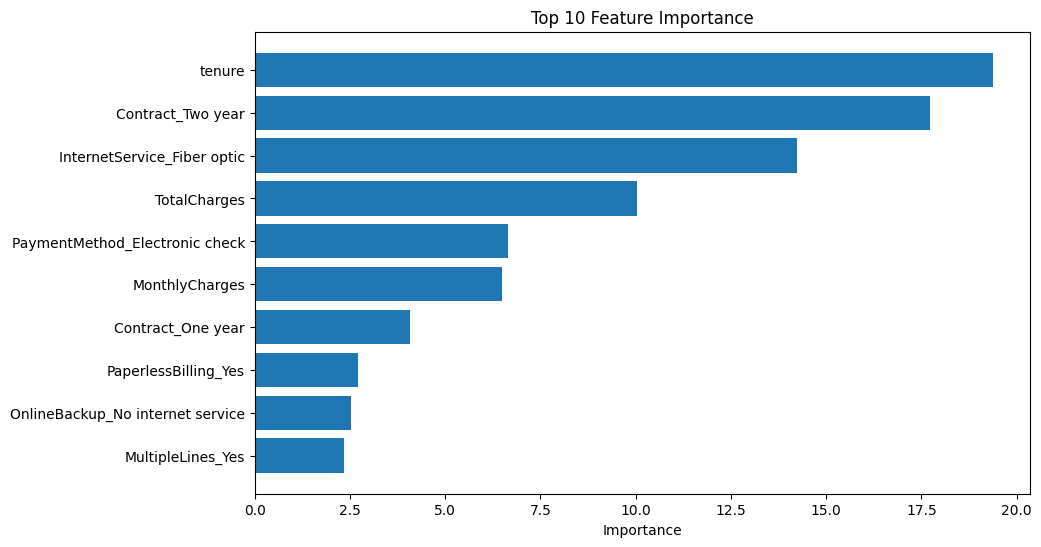

In [25]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.title('Top 10 Feature Importance')

plt.gca().invert_yaxis()

plt.show()

In [26]:
test_df = pd.read_csv("test.csv")

In [27]:
test_ids = test_df['id']

In [28]:
test_processed = test_df.drop('id', axis=1)

test_processed = pd.get_dummies(
    test_processed,
    drop_first=True
)

In [29]:
test_processed = test_processed.reindex(
    columns=x.columns,
    fill_value=0
)

In [30]:
test_prob = model.predict_proba(test_processed)[:,1]

In [31]:
submission = pd.DataFrame({
    'id': test_ids,
    'Churn': test_prob
})

In [34]:
submission.to_csv(
    'submission.csv',
    index=False
)

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, y_pred)

print(cm)

[[85190  6886]
 [ 9603 17160]]


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.93      0.91     92076
           1       0.71      0.64      0.68     26763

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839

